In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from pathlib import Path
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.manifold import TSNE

%matplotlib inline

print("NumPy 版本：", np.__version__)
print("Matplotlib 版本：", plt.matplotlib.__version__)

NumPy 版本： 2.5.1
Matplotlib 版本： 3.11.1


### 1.1 创建统一的实验环境

科研实验应尽量可复现，因此：

- 固定随机种子；
- 所有图片统一保存到 `figures/`；
- 设置统一字体大小和图片分辨率；
- Windows 有中文字体时使用中文，否则自动退回英文，避免方框和 `Glyph missing` 警告。

In [5]:
# 固定随机数生成器，使每次运行得到相同的模拟数据
rng = np.random.default_rng(42)

# 创建图片输出目录
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 检查系统可用字体，优先选择中文字体
available_fonts = {font.name for font in fm.fontManager.ttflist}
cjk_candidates = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Noto Sans SC",
    "Microsoft JhengHei",
    "SimSun",
]

CJK_FONT = next(
    (font_name for font_name in cjk_candidates if font_name in available_fonts),
    None
)

if CJK_FONT:
    plt.rcParams["font.sans-serif"] = [CJK_FONT, "DejaVu Sans"]
    print("已启用中文字体：", CJK_FONT)
else:
    print("未检测到中文字体，图内文字将使用英文，以避免乱码。")

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 9

def text(zh: str, en: str) -> str:
    # 有中文字体时返回中文，否则返回英文
    return zh if CJK_FONT else en

def save_report_figure(fig, stem: str):
    # 同时保存 PNG 和 PDF
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white"
    )

    assert png_path.exists()
    assert pdf_path.exists()

    print("已保存：", png_path)
    print("已保存：", pdf_path)
    return png_path, pdf_path

已启用中文字体： Microsoft YaHei


## 2. Matplotlib 的基本结构
推荐使用面向对象写法：
```python
fig, ax = plt.subplots()
ax.plot(...)
ax.set_title(...)
ax.set_xlabel(...)
ax.set_ylabel(...)
fig.tight_layout()
fig.savefig(...)
plt.show()
```
### 两个核心对象
- `fig`：整张画布，可以包含一幅或多幅子图。
- `ax`：真正绘图的坐标区域。标题、坐标轴、图例等通常通过 `ax` 设置。
### 一幅科研图的最低要求
通常至少应包含：
1. 清晰的标题；
2. 横坐标名称；
3. 纵坐标名称；
4. 多条数据时提供图例；
5. 必要时添加网格、颜色条、数值标签或关键点说明；
6. 使用 `tight_layout()` 避免文字被截断；
7. 使用 `savefig()` 保存报告素材。

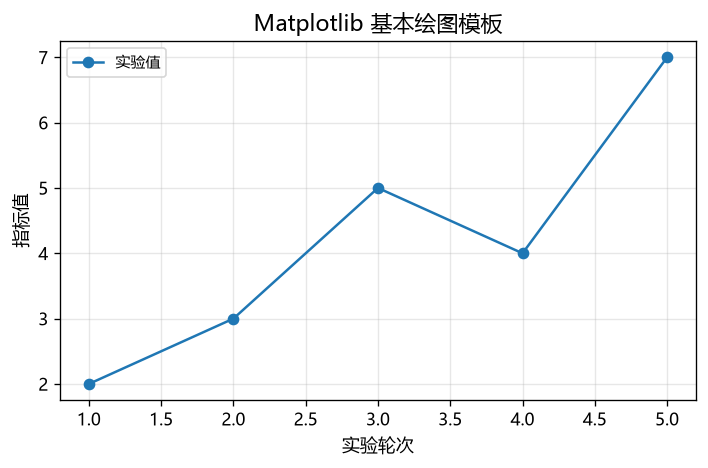

In [6]:
# 最小绘图模板
x_demo = np.arange(1, 6)
y_demo = np.array([2, 3, 5, 4, 7])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_demo, y_demo, marker="o", label=text("实验值", "Experiment"))
ax.set_title(text("Matplotlib 基本绘图模板", "Basic Matplotlib Template"))
ax.set_xlabel(text("实验轮次", "Round"))
ax.set_ylabel(text("指标值", "Metric"))
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

# 3. 图表一：训练 Loss / Accuracy 折线图

## 3.1 使用场景

训练曲线用于判断模型训练过程是否正常：

- 训练 Loss 持续下降：模型正在拟合训练数据；
- 验证 Loss 先下降后上升：可能出现过拟合；
- Accuracy 上升后趋于稳定：模型逐渐收敛；
- 训练集和验证集差距很大：模型泛化能力可能不足。

本例使用模拟数据，分别绘制 Loss 和 Accuracy。使用两个子图比把不同量纲强行放在一个坐标轴上更易读。

In [8]:
# 生成可复现的模拟训练数据
epochs = np.arange(1, 41)

train_loss = (
    1.40 * np.exp(-epochs / 11)
    + 0.10
    + rng.normal(0, 0.015, size=epochs.size)
)

val_loss = (
    1.48 * np.exp(-epochs / 13)
    + 0.16
    + rng.normal(0, 0.022, size=epochs.size)
)

train_acc = (
    0.50
    + 0.46 * (1 - np.exp(-epochs / 10))
    + rng.normal(0, 0.006, size=epochs.size)
)

val_acc = (
    0.48
    + 0.42 * (1 - np.exp(-epochs / 12))
    + rng.normal(0, 0.009, size=epochs.size)
)

# 基本检查
assert epochs.shape == train_loss.shape == val_loss.shape
assert epochs.shape == train_acc.shape == val_acc.shape
assert np.all((train_acc >= 0) & (train_acc <= 1))
assert np.all((val_acc >= 0) & (val_acc <= 1))

print("Epoch 数量：", epochs.size)
print("最低验证 Loss 所在 Epoch：", epochs[np.argmin(val_loss)])
print("最高验证 Accuracy：", val_acc.max())

Epoch 数量： 40
最低验证 Loss 所在 Epoch： 40
最高验证 Accuracy： 0.895000800507716


已保存： figures\01_training_curves.png
已保存： figures\01_training_curves.pdf


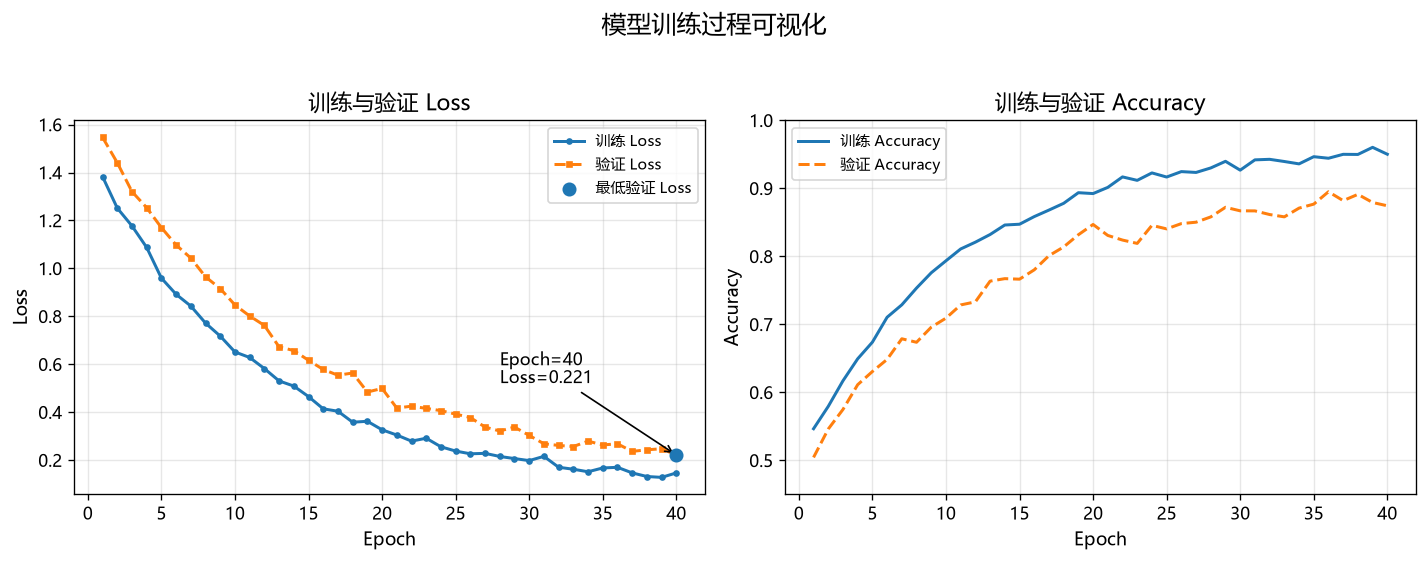

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 左图：Loss
axes[0].plot(
    epochs,
    train_loss,
    marker="o",
    markersize=3,
    linewidth=1.8,
    label=text("训练 Loss", "Train Loss")
)
axes[0].plot(
    epochs,
    val_loss,
    marker="s",
    markersize=3,
    linewidth=1.8,
    linestyle="--",
    label=text("验证 Loss", "Validation Loss")
)

best_epoch = int(epochs[np.argmin(val_loss)])
best_val_loss = float(val_loss.min())

axes[0].scatter(
    [best_epoch],
    [best_val_loss],
    s=55,
    zorder=5,
    label=text("最低验证 Loss", "Minimum Validation Loss")
)
axes[0].annotate(
    f"Epoch={best_epoch}\nLoss={best_val_loss:.3f}",
    xy=(best_epoch, best_val_loss),
    xytext=(best_epoch - 12, best_val_loss + 0.30),
    arrowprops={"arrowstyle": "->"},
)

axes[0].set_title(text("训练与验证 Loss", "Training and Validation Loss"))
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 右图：Accuracy
axes[1].plot(
    epochs,
    train_acc,
    linewidth=1.8,
    label=text("训练 Accuracy", "Train Accuracy")
)
axes[1].plot(
    epochs,
    val_acc,
    linewidth=1.8,
    linestyle="--",
    label=text("验证 Accuracy", "Validation Accuracy")
)
axes[1].set_title(text("训练与验证 Accuracy", "Training and Validation Accuracy"))
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.45, 1.0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle(
    text("模型训练过程可视化", "Model Training Process"),
    fontsize=15,
    y=1.03
)

fig.tight_layout()

training_paths = save_report_figure(fig, "01_training_curves")
plt.show()

### 3.2 读图练习

观察图表并回答：

1. 训练 Loss 和验证 Loss 是否都在下降？
2. 验证 Loss 最低点出现在哪个 Epoch？
3. 训练 Accuracy 是否明显高于验证 Accuracy？
4. 是否有明显的过拟合迹象？

### 3.3 实践任务

修改代码并重新运行：

- 将 Epoch 数量改为 60；
- 把验证 Loss 的噪声从 `0.022` 改为 `0.05`；
- 把折线改成不同线型；
- 将图片另存为 `01_training_curves_practice.png`。

# 4. 图表二：混淆矩阵

## 4.1 使用场景

混淆矩阵用于分析分类模型“具体错在哪里”。

- 行：真实类别；
- 列：预测类别；
- 对角线：预测正确的样本；
- 非对角线：误分类样本。

仅看 Accuracy 可能掩盖类别间差异；混淆矩阵能显示模型容易混淆哪些类别。

In [10]:
# 三分类模拟结果
class_names = np.array([
    text("正常", "Normal"),
    text("有害", "Harmful"),
    text("不确定", "Uncertain")
])

y_true = np.array([
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    2, 2, 2, 2, 2, 2, 2, 2, 2, 2
])

y_pred = np.array([
    0, 0, 0, 0, 0, 0, 1, 0, 2, 0,
    1, 1, 1, 0, 1, 1, 2, 1, 1, 0,
    2, 2, 2, 2, 1, 2, 2, 0, 2, 2
])

cm = confusion_matrix(y_true, y_pred)

assert cm.shape == (3, 3)
assert cm.sum() == y_true.size

print("混淆矩阵：")
print(cm)
print("样本总数：", cm.sum())

混淆矩阵：
[[8 1 1]
 [2 7 1]
 [1 1 8]]
样本总数： 30


已保存： figures\02_confusion_matrix.png
已保存： figures\02_confusion_matrix.pdf


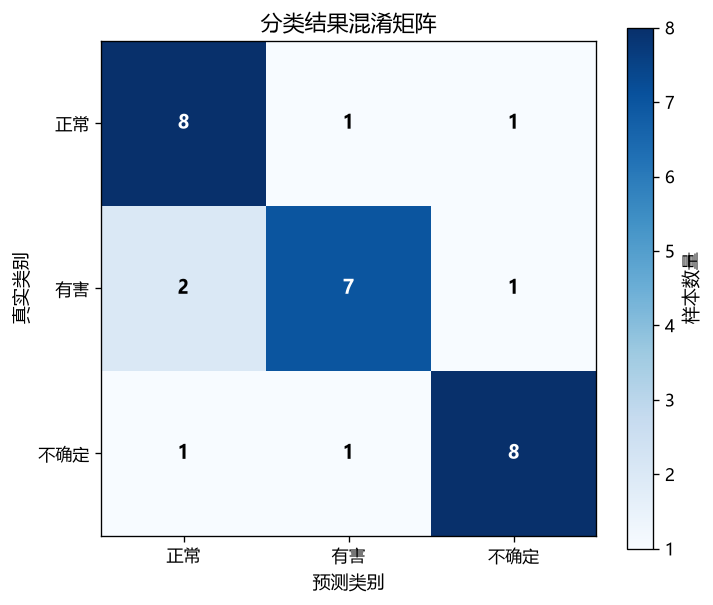

In [11]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))

image = ax.imshow(cm, cmap="Blues")

# 设置类别刻度
positions = np.arange(class_names.size)
ax.set_xticks(positions, labels=class_names)
ax.set_yticks(positions, labels=class_names)

ax.set_title(text("分类结果混淆矩阵", "Classification Confusion Matrix"))
ax.set_xlabel(text("预测类别", "Predicted Label"))
ax.set_ylabel(text("真实类别", "True Label"))

# 在每个格子中写入数值
threshold = cm.max() / 2

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(
            col,
            row,
            str(cm[row, col]),
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white" if cm[row, col] > threshold else "black"
        )

# 颜色条说明数值大小
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label(text("样本数量", "Sample Count"))

fig.tight_layout()

confusion_paths = save_report_figure(fig, "02_confusion_matrix")
plt.show()

### 4.2 如何解释混淆矩阵

例如，第二行表示真实类别为“有害”的样本：

- 第二行第二列：被正确预测为“有害”；
- 第二行第一列：被误判为“正常”；
- 第二行第三列：被误判为“不确定”。

安全检测任务中，通常需要特别关注：

> 真实有害内容被预测为正常内容的数量，因为这属于漏检。

### 4.3 实践任务

1. 修改几个 `y_pred` 标签，观察矩阵如何变化。
2. 计算每一行的归一化比例：

```python
cm_normalized = cm / cm.sum(axis=1, keepdims=True)
```

3. 将格子内的数量改成百分比格式。

# 5. 图表三：模型性能对比柱状图

## 5.1 使用场景

柱状图适合比较：

- 不同模型；
- 不同输入模态；
- 不同消融实验设置；
- 不同数据集上的指标。

本例比较四个模型的 Accuracy 和 F1。分组柱状图适合在同一模型下比较多个指标。

In [13]:
models = np.array(["TF-IDF+LR", "TextCNN", "BiLSTM", "BERT"])
accuracy = np.array([0.861, 0.892, 0.908, 0.941])
f1_score = np.array([0.847, 0.881, 0.899, 0.935])

assert models.size == accuracy.size == f1_score.size
assert np.all((accuracy >= 0) & (accuracy <= 1))
assert np.all((f1_score >= 0) & (f1_score <= 1))

best_model = models[np.argmax(f1_score)]
print("F1 最高的模型：", best_model)

F1 最高的模型： BERT


已保存： figures\03_model_comparison.png
已保存： figures\03_model_comparison.pdf


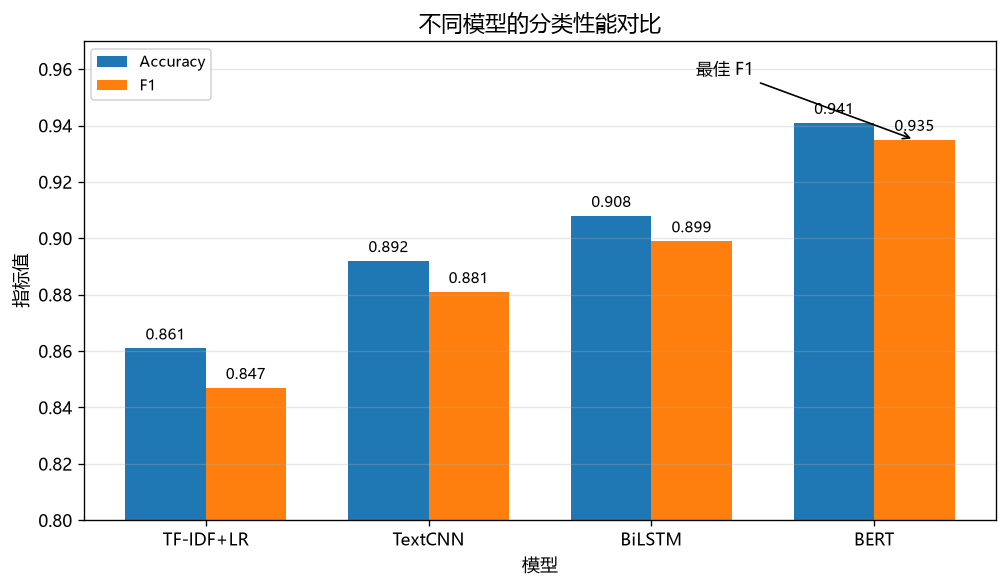

In [14]:
x = np.arange(models.size)
bar_width = 0.36

fig, ax = plt.subplots(figsize=(8.5, 5))

accuracy_bars = ax.bar(
    x - bar_width / 2,
    accuracy,
    width=bar_width,
    label="Accuracy"
)

f1_bars = ax.bar(
    x + bar_width / 2,
    f1_score,
    width=bar_width,
    label="F1"
)

ax.set_title(text("不同模型的分类性能对比", "Model Performance Comparison"))
ax.set_xlabel(text("模型", "Model"))
ax.set_ylabel(text("指标值", "Score"))
ax.set_xticks(x, labels=models)
ax.set_ylim(0.80, 0.97)
ax.grid(axis="y", alpha=0.3)
ax.legend()

# 在柱子上显示具体数值
ax.bar_label(accuracy_bars, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(f1_bars, fmt="%.3f", padding=3, fontsize=9)

# 标注最佳模型
best_index = int(np.argmax(f1_score))
ax.annotate(
    text("最佳 F1", "Best F1"),
    xy=(x[best_index] + bar_width / 2, f1_score[best_index]),
    xytext=(x[best_index] - 0.8, 0.958),
    arrowprops={"arrowstyle": "->"}
)

fig.tight_layout()

bar_paths = save_report_figure(fig, "03_model_comparison")
plt.show()

### 5.2 柱状图设计原则

- 纵轴最好明确写出指标名称或统一写成 `Score`；
- 指标范围在 0～1 时，不要忘记设置合理的 `ylim`；
- 对数量不多的柱子，可直接显示具体数值；
- 不要使用过多颜色；
- 如果类别很多，考虑使用水平柱状图 `barh()`。

### 5.3 实践任务

1. 增加一组 Recall 数据；
2. 增加一个模型；
3. 将图改为水平柱状图；
4. 标注 Accuracy 和 F1 的差值。

# 6. 图表四：ROC 曲线

## 6.1 使用场景

ROC 曲线用于二分类模型的阈值评估。

- 横轴 FPR：假正率；
- 纵轴 TPR：真正率，也等于 Recall；
- 曲线越靠近左上角越好；
- 对角虚线表示随机猜测；
- AUC 越接近 1，模型整体判别能力越强。

本例比较两个模型的 ROC 曲线。

In [16]:
# 构造二分类真实标签
n_negative = 180
n_positive = 160

roc_y_true = np.r_[
    np.zeros(n_negative, dtype=int),
    np.ones(n_positive, dtype=int)
]

# 模型 A：区分能力较好
scores_model_a = np.r_[
    rng.beta(2.0, 5.0, size=n_negative),
    rng.beta(5.0, 2.0, size=n_positive)
]

# 模型 B：区分能力稍弱
scores_model_b = np.r_[
    rng.beta(2.5, 4.0, size=n_negative),
    rng.beta(4.0, 2.5, size=n_positive)
]

assert roc_y_true.shape == scores_model_a.shape == scores_model_b.shape
assert np.all((scores_model_a >= 0) & (scores_model_a <= 1))
assert np.all((scores_model_b >= 0) & (scores_model_b <= 1))

fpr_a, tpr_a, thresholds_a = roc_curve(roc_y_true, scores_model_a)
fpr_b, tpr_b, thresholds_b = roc_curve(roc_y_true, scores_model_b)

auc_a = roc_auc_score(roc_y_true, scores_model_a)
auc_b = roc_auc_score(roc_y_true, scores_model_b)

print(f"Model A AUC：{auc_a:.3f}")
print(f"Model B AUC：{auc_b:.3f}")

Model A AUC：0.941
Model B AUC：0.838


已保存： figures\04_roc_curves.png
已保存： figures\04_roc_curves.pdf


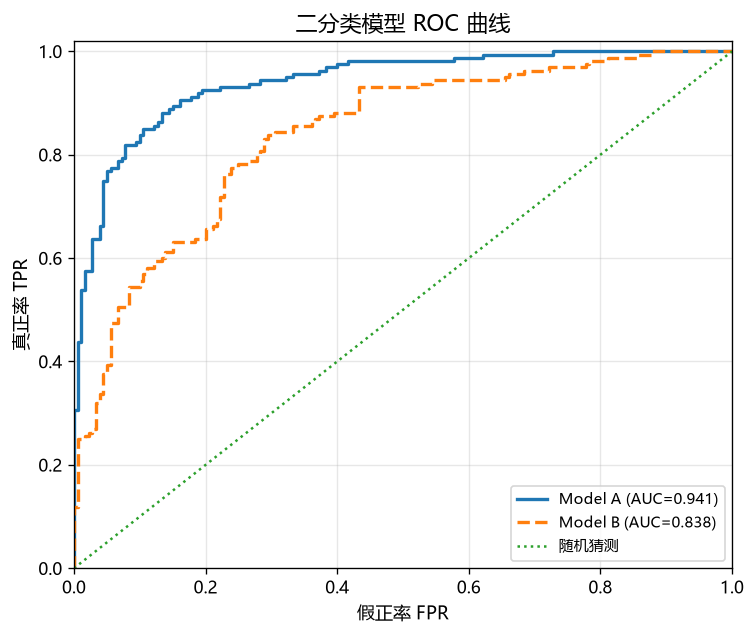

In [17]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))

ax.plot(
    fpr_a,
    tpr_a,
    linewidth=2,
    label=f"Model A (AUC={auc_a:.3f})"
)

ax.plot(
    fpr_b,
    tpr_b,
    linewidth=2,
    linestyle="--",
    label=f"Model B (AUC={auc_b:.3f})"
)

# 随机分类器基线
ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=1.5,
    label=text("随机猜测", "Random Guess")
)

ax.set_title(text("二分类模型 ROC 曲线", "ROC Curves for Binary Classifiers"))
ax.set_xlabel(text("假正率 FPR", "False Positive Rate"))
ax.set_ylabel(text("真正率 TPR", "True Positive Rate"))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

fig.tight_layout()

roc_paths = save_report_figure(fig, "04_roc_curves")
plt.show()

### 6.2 ROC 曲线注意事项

- ROC 需要模型输出的概率或连续分数，而不是最终的 0/1 标签；
- `predict_proba(X)[:, 1]` 通常表示正类概率；
- AUC 只能反映整体排序能力，不能直接替代 Precision、Recall 和 F1；
- 数据极度不平衡时，也应关注 Precision-Recall 曲线。

### 6.3 实践任务

1. 修改 Model B 的分布参数，观察 AUC 变化；
2. 增加第三条 ROC 曲线；
3. 在图中标注某个阈值对应的点；
4. 解释为什么随机猜测对应对角线。

# 7. 图表五：t-SNE 特征空间散点图

## 7.1 使用场景

神经网络产生的特征通常是几十维、几百维甚至更高维，无法直接画图。

t-SNE 可以把高维特征降到二维，用于观察：

- 不同类别是否形成聚类；
- 类别之间是否发生重叠；
- 融合特征是否比单模态特征更容易区分；
- 模型训练前后的特征空间是否发生变化。

注意：

> t-SNE 主要用于可视化，不应直接把二维距离解释为原始高维空间中的精确距离。

In [18]:
# 创建 3 类、每类 80 个样本的 32 维模拟特征
samples_per_class = 80
feature_dim = 32

center_0 = np.r_[np.full(8, 2.5), np.zeros(feature_dim - 8)]
center_1 = np.r_[np.zeros(8), np.full(8, 2.5), np.zeros(feature_dim - 16)]
center_2 = np.r_[np.zeros(16), np.full(8, 2.5), np.zeros(feature_dim - 24)]

high_dim_features = np.vstack([
    center_0 + rng.normal(0, 0.9, size=(samples_per_class, feature_dim)),
    center_1 + rng.normal(0, 0.9, size=(samples_per_class, feature_dim)),
    center_2 + rng.normal(0, 0.9, size=(samples_per_class, feature_dim)),
])

feature_labels = np.repeat([0, 1, 2], samples_per_class)

assert high_dim_features.shape == (240, 32)
assert feature_labels.shape == (240,)

print("高维特征形状：", high_dim_features.shape)

高维特征形状： (240, 32)


In [19]:
tsne = TSNE(
    n_components=2,
    perplexity=25,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

features_2d = tsne.fit_transform(high_dim_features)

assert features_2d.shape == (high_dim_features.shape[0], 2)

print("降维后特征形状：", features_2d.shape)

降维后特征形状： (240, 2)


已保存： figures\05_tsne_features.png
已保存： figures\05_tsne_features.pdf


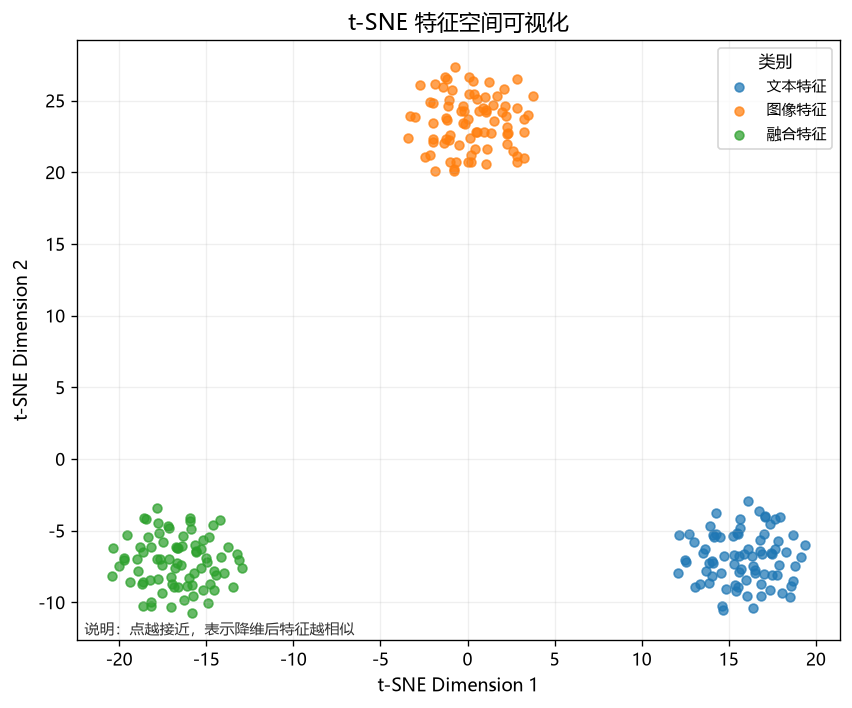

In [20]:
tsne_class_names = [
    text("文本特征", "Text"),
    text("图像特征", "Image"),
    text("融合特征", "Fusion")
]

fig, ax = plt.subplots(figsize=(7.2, 6))

for class_id, class_name in enumerate(tsne_class_names):
    mask = feature_labels == class_id

    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        s=28,
        alpha=0.72,
        label=class_name
    )

ax.set_title(text("t-SNE 特征空间可视化", "t-SNE Feature Space Visualization"))
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.grid(True, alpha=0.2)
ax.legend(title=text("类别", "Class"))

# t-SNE 轴本身没有实际物理单位，因此图中补充必要说明
ax.text(
    0.01,
    0.01,
    text(
        "说明：点越接近，表示降维后特征越相似",
        "Note: Nearby points are more similar after projection"
    ),
    transform=ax.transAxes,
    fontsize=9,
    alpha=0.8
)

fig.tight_layout()

tsne_paths = save_report_figure(fig, "05_tsne_features")
plt.show()

### 7.2 t-SNE 参数说明

- `n_components=2`：降到二维；
- `perplexity`：近似控制每个点考虑的邻居数量；
- `random_state=42`：保证结果可复现；
- `init="pca"`：先使用 PCA 初始化；
- `learning_rate="auto"`：自动设置学习率。

### 常见限制

1. `perplexity` 必须小于样本数量；
2. 不同随机种子可能产生不同布局；
3. 图中的整体方向、旋转和绝对坐标通常没有实际意义；
4. t-SNE 运行时间比普通绘图长。

### 7.3 实践任务

1. 将 `perplexity` 分别改为 5、15、40；
2. 增大特征噪声，从 `0.9` 改成 `1.5`；
3. 比较类别间重叠程度；
4. 把点大小 `s` 和透明度 `alpha` 调整到更适合报告的效果。

# 8. 图片保存与报告使用

## 8.1 推荐格式

### PNG

```python
fig.savefig("figure.png", dpi=300, bbox_inches="tight")
```

适合：

- Word
- PPT
- 网页
- 快速查看

`dpi=300` 通常可以满足报告和打印需求。

### PDF

```python
fig.savefig("figure.pdf", bbox_inches="tight")
```

适合：

- LaTeX
- 正式实验报告
- 需要放大但保持清晰的矢量图

### SVG（可选）

```python
fig.savefig("figure.svg", bbox_inches="tight")
```

适合网页和矢量编辑软件。

## 8.2 保存顺序

推荐：

```python
fig.tight_layout()
fig.savefig(...)
plt.show()
```

不要依赖在 `plt.show()` 之后再保存；某些环境中显示后画布可能被清空或关闭。

## 8.3 文件命名建议

采用有序且可读的名称：

```text
01_training_curves.png
02_confusion_matrix.png
03_model_comparison.png
04_roc_curves.png
05_tsne_features.png
```

In [21]:
# 查看已经生成的图片
generated_files = sorted(FIG_DIR.glob("*"))

print("当前 figures/ 目录中的文件：")
for file_path in generated_files:
    print(
        f"- {file_path.name:<30} "
        f"{file_path.stat().st_size / 1024:>8.1f} KB"
    )

# 五幅图，每幅同时保存 PNG 和 PDF，应至少得到 10 个文件
assert len(generated_files) >= 10
print("\n图片导出检查通过。")

当前 figures/ 目录中的文件：
- 01_training_curves.pdf             23.6 KB
- 01_training_curves.png            253.6 KB
- 02_confusion_matrix.pdf            25.3 KB
- 02_confusion_matrix.png            72.9 KB
- 03_model_comparison.pdf            23.1 KB
- 03_model_comparison.png           111.0 KB
- 04_roc_curves.pdf                  21.2 KB
- 04_roc_curves.png                 119.4 KB
- 05_tsne_features.pdf               29.1 KB
- 05_tsne_features.png              245.6 KB

图片导出检查通过。
